In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 1. 加载原始数据
file_path = r"D:\code\python\ML\Project\air+quality\AirQualityUCI.csv"
df = pd.read_csv(file_path, sep=';', decimal=',')

# 2. 基础清洗（删除全空行列，统一缺失值标记）
df = df.dropna(how='all', axis=1).dropna(how='all', axis=0)
df.replace(-200, np.nan, inplace=True)

# 3. 特征工程：时间维度提取
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df['Hour'] = df['DateTime'].dt.hour
df['Month'] = df['DateTime'].dt.month
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
# 对小时进行独热编码（空气质量受小时影响显著）
df = pd.get_dummies(df, columns=['Hour'], prefix='H')

# 4. 记录缺失状态（在插值前操作，保留原始缺失信息作为特征）
df['CO_is_missing'] = df['CO(GT)'].isna().astype(int)

# 5. 准备数值特征列
df_numeric = df.drop(['Date', 'Time', 'DateTime'], axis=1)
cols_to_scale = ['CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
                 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

output_dir = r"D:\code\python\ML\Project\air&quality_test\\"

# =====================================================================
# [新增] 6. 针对 Clustering & t-SNE 的全局数据处理 (AirQuality_Fully_Preprocessed.csv)
# =====================================================================
# 聚类和流形学习需要全局视角，因此进行全局插值和归一化
df_clustering = df_numeric.copy()
df_clustering = df_clustering.interpolate(method='linear', limit_direction='both')

scaler_global = StandardScaler()
df_clustering[cols_to_scale] = scaler_global.fit_transform(df_clustering[cols_to_scale])
df_clustering.to_csv(output_dir + "AirQuality_Fully_Preprocessed.csv", index=False)


# =====================================================================
# 7. 针对 Prediction 的严格时间序列切分与处理 (Train/Val/Test)
# =====================================================================
# 三段式顺序切分 (Train: 70%, Val: 15%, Test: 15%)
# 注意：shuffle=False 是时间序列处理的生命线，严格防止未来数据泄露
train_val_df, test_df = train_test_split(df_numeric, test_size=0.15, shuffle=False)
train_df, val_df = train_test_split(train_val_df, test_size=0.176, shuffle=False) # 0.85 * 0.176 ≈ 0.15

# 每一段独立插值，避免未来信息回流
train_df = train_df.interpolate(method='linear', limit_direction='both')
val_df = val_df.interpolate(method='linear', limit_direction='both')
test_df = test_df.interpolate(method='linear', limit_direction='both')

# 数据标准化：只在训练集上进行 fit
scaler_predict = StandardScaler()
scaler_predict.fit(train_df[cols_to_scale])

# 将训练集学到的均值和方差应用到所有子集
train_df[cols_to_scale] = scaler_predict.transform(train_df[cols_to_scale])
val_df[cols_to_scale] = scaler_predict.transform(val_df[cols_to_scale])
test_df[cols_to_scale] = scaler_predict.transform(test_df[cols_to_scale])

# 导出预测模型使用的数据集
train_df.to_csv(output_dir + "AirQuality_Train.csv", index=False)
val_df.to_csv(output_dir + "AirQuality_Val.csv", index=False)
test_df.to_csv(output_dir + "AirQuality_Test.csv", index=False)

# =====================================================================
# 8. 打印总结报告
# =====================================================================
print("--- 🚀 数据预处理与特征工程完成 ---")
print(f"全局聚类数据集样本数 (Clustering): {len(df_clustering)}")
print(f"训练集样本数 (Train 70%): {len(train_df)}")
print(f"验证集样本数 (Val  15%): {len(val_df)}")
print(f"测试集样本数 (Test 15%): {len(test_df)}")
print(f"\n📁 所有数据已保存至: {output_dir}")

print("\n📊 训练集预览 (已完成标准化)：")
print(train_df[cols_to_scale].head())
import joblib

# 保存那个已经在训练集上 fit 过的 scaler
joblib.dump(scaler_predict, 'air_quality_scaler.pkl')

--- 🚀 数据预处理与特征工程完成 ---
全局聚类数据集样本数 (Clustering): 9357
训练集样本数 (Train 70%): 6553
验证集样本数 (Val  15%): 1400
测试集样本数 (Test 15%): 1404

📁 所有数据已保存至: D:\code\python\ML\Project\air&quality_test\\

📊 训练集预览 (已完成标准化)：
     CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)   NOx(GT)  \
0  0.322376     1.198293 -1.327128  0.148118       0.301864 -0.216082   
1 -0.101855     0.888277 -1.755875 -0.176375      -0.037921 -0.556798   
2  0.039555     1.389773 -2.026662 -0.228294      -0.097663 -0.405368   
3  0.039555     1.271237 -2.116925 -0.202334      -0.064058 -0.183633   
4 -0.384676     0.797096 -2.444126 -0.552786      -0.482254 -0.405368   

   PT08.S3(NOx)   NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)         T        RH  \
0      0.792431  0.393814      0.387616     0.692832 -1.058639  0.062195   
1      1.261445 -0.142932     -0.072621    -0.093136 -1.097895 -0.006969   
2      1.126306  0.419373     -0.086463     0.177704 -1.281089  0.356140   
3      0.935520  0.623848      0.013890     0.520237 -

['air_quality_scaler.pkl']

2D：mouth
3，4月聚类明显，其余无明显聚类

正在计算 t-SNE,请稍候约十几秒...


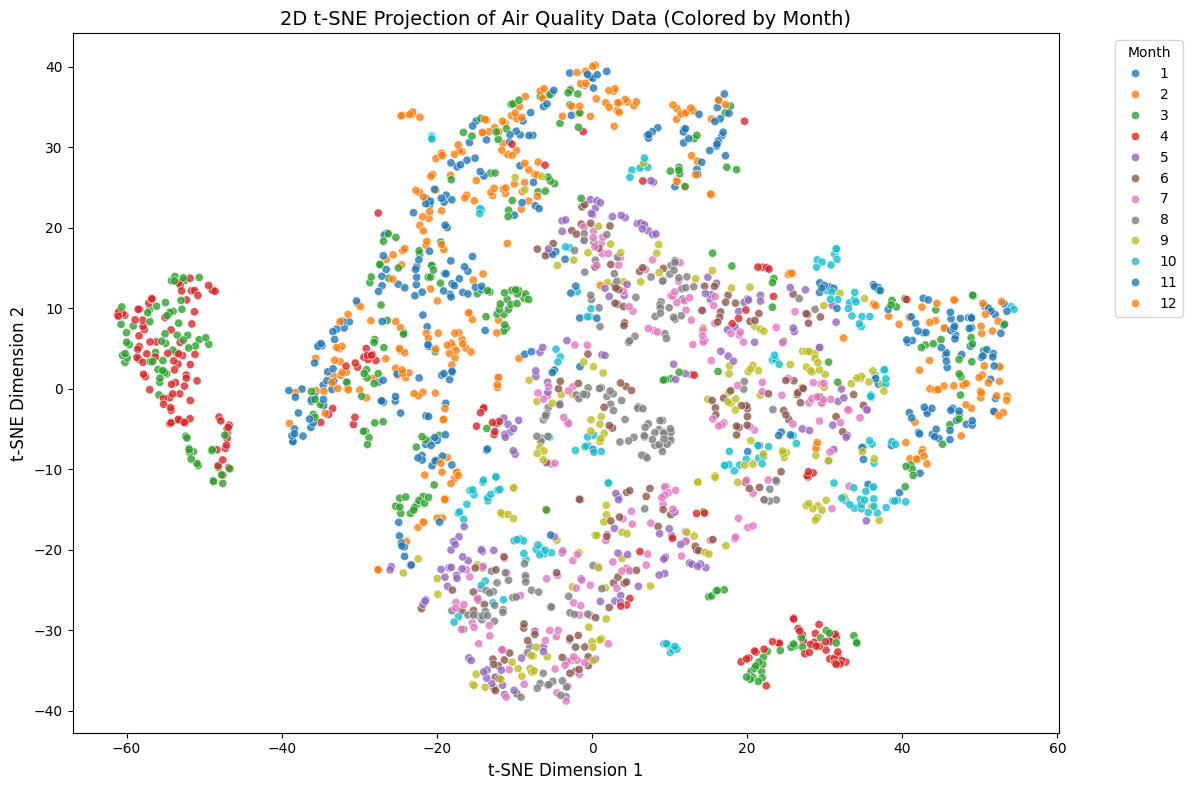

In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. 读取你刚刚预处理完的干净数据
file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)

# 2. 【关键】随机抽样 2000 条数据以加速 t-SNE 计算
df_sampled = df.sample(n=2000, random_state=42)

# 3. 确定特征 (X) 和 颜色标签 (y)
# 我们提取 'Month' 作为颜色标签，其余所有列作为降维的特征输入
y = df_sampled['Month']
X = df_sampled.drop(columns=['Month']) 

# 4. 初始化并运行 t-SNE
# perplexity (困惑度) 是 t-SNE 最重要的参数，通常设为 30
print("正在计算 t-SNE,请稍候约十几秒...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, init='pca', learning_rate='auto')
tsne_results = tsne.fit_transform(X)

# 5. 将结果转换为 DataFrame 以便使用 seaborn 画图
df_tsne = pd.DataFrame({
    't-SNE Dimension 1': tsne_results[:, 0],
    't-SNE Dimension 2': tsne_results[:, 1],
    'Month': y.values
})

# 6. 绘制散点图 (Scatter Plot)
plt.figure(figsize=(12, 8))
# 使用 'Month' 作为颜色区分 (hue)，采用明亮的调色板
scatter = sns.scatterplot(
    x="t-SNE Dimension 1", y="t-SNE Dimension 2",
    hue="Month",
    palette="tab10",  # 使用适合多分类的调色板
    data=df_tsne,
    legend="full",
    alpha=0.8
)

plt.title('2D t-SNE Projection of Air Quality Data (Colored by Month)', fontsize=14)
plt.xlabel('t-SNE Dimension 1', fontsize=12)
plt.ylabel('t-SNE Dimension 2', fontsize=12)
# 将图例移到图表外侧以免遮挡数据
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Matrix Data
tokens = ["Your", "journey", "starts", "with", "one", "step"]
n = len(tokens)
np.random.seed(42)
raw_scores = np.random.uniform(5, 15, size=(n, n))

# Setup square figure
fig, ax = plt.subplots(figsize=(8, 8), facecolor='white')
plt.subplots_adjust(left=0.15, right=0.95, top=0.85, bottom=0.15)

def draw_matrix(matrix, mask_indices=None, show_inf=False, is_softmax=False):
    ax.clear()
    ax.set_facecolor('white')
    
    # Define colors
    if is_softmax:
        display_matrix = np.copy(matrix)
        cmap = "Blues"
    else:
        display_matrix = np.copy(matrix)
        cmap = "Greys"

    # Background grid
    im = ax.imshow(display_matrix, cmap=cmap, alpha=0.3 if not is_softmax else 0.8)
    
    # Labels
    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))
    ax.set_xticklabels(tokens, fontsize=12)
    ax.set_yticklabels(tokens, fontsize=12)
    ax.xaxis.tick_top()
    
    # Text in cells
    for i in range(n):
        for j in range(n):
            val_text = ""
            color = "black"
            
            # Masking logic
            if mask_indices is not None and j > i:
                if show_inf:
                    val_text = r"$-\infty$"
                    color = "red"
                else:
                    val_text = f"{matrix[i, j]:.1f}"
                    color = "gray"
            else:
                if is_softmax:
                    val_text = f"{matrix[i, j]:.2f}"
                else:
                    val_text = f"{matrix[i, j]:.1f}"
            
            ax.text(j, i, val_text, ha="center", va="center", color=color, 
                    fontsize=14, fontweight='bold' if color=="red" else 'normal')

    # Grid lines
    ax.set_xticks(np.arange(n+1)-.5, minor=True)
    ax.set_yticks(np.arange(n+1)-.5, minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", size=0)

def animate(frame):
    # Frame logic
    if frame < 20:
        # Phase 1: Show Raw Scores
        draw_matrix(raw_scores)
        ax.set_title("1. Raw Scores ($Q K^T$)\nBidirectional (Unmasked)", fontsize=16, pad=20)
    
    elif frame < 40:
        # Phase 2: Highlight Future Tokens
        draw_matrix(raw_scores, mask_indices=True)
        ax.set_title("2. Identifying Future Tokens\n(Upper Triangular Part)", fontsize=16, pad=20, color='red')
        
    elif frame < 65:
        # Phase 3: Apply -Infinity
        draw_matrix(raw_scores, mask_indices=True, show_inf=True)
        ax.set_title("3. Applying Mask ($+ M$)\nSet Future to $-\infty$", fontsize=16, pad=20, color='red')
        
    else:
        # Phase 4: Softmax
        # Calculate masked softmax
        m_scores = np.copy(raw_scores)
        for i in range(n):
            for j in range(n):
                if j > i: m_scores[i, j] = -1e9 # proxy for -inf
        
        # Row-wise softmax
        exp_m = np.exp(m_scores - np.max(m_scores, axis=1, keepdims=True))
        softmax_m = exp_m / np.sum(exp_m, axis=1, keepdims=True)
        
        draw_matrix(softmax_m, is_softmax=True)
        ax.set_title("4. Output after Softmax\nFuture Weights become 0", fontsize=16, pad=20, color='blue')

# Create Animation
ani = animation.FuncAnimation(fig, animate, frames=90, interval=120)

# Save as Square GIF with white background for WPS
ani.save('masked_attention_calculation.gif', writer='pillow', savefig_kwargs={'facecolor': 'white'})
plt.close()

2D: NO2 + Daytime
无明显聚合

参与降维的特征共 12 个: ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']
正在计算 t-SNE (Perplexity=200, Iterations=3000)...


C:\Users\36024\AppData\Local\Temp\ipykernel_18048\2410047751.py:89: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm, label='Normalized PT08.S4(NO2) Reading')


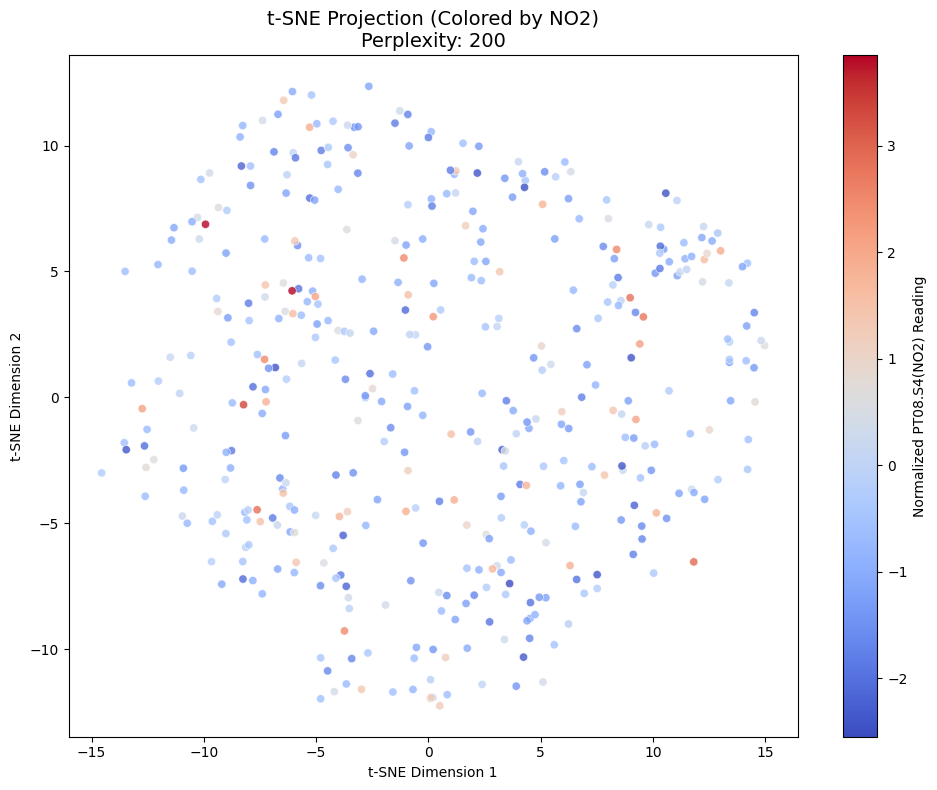

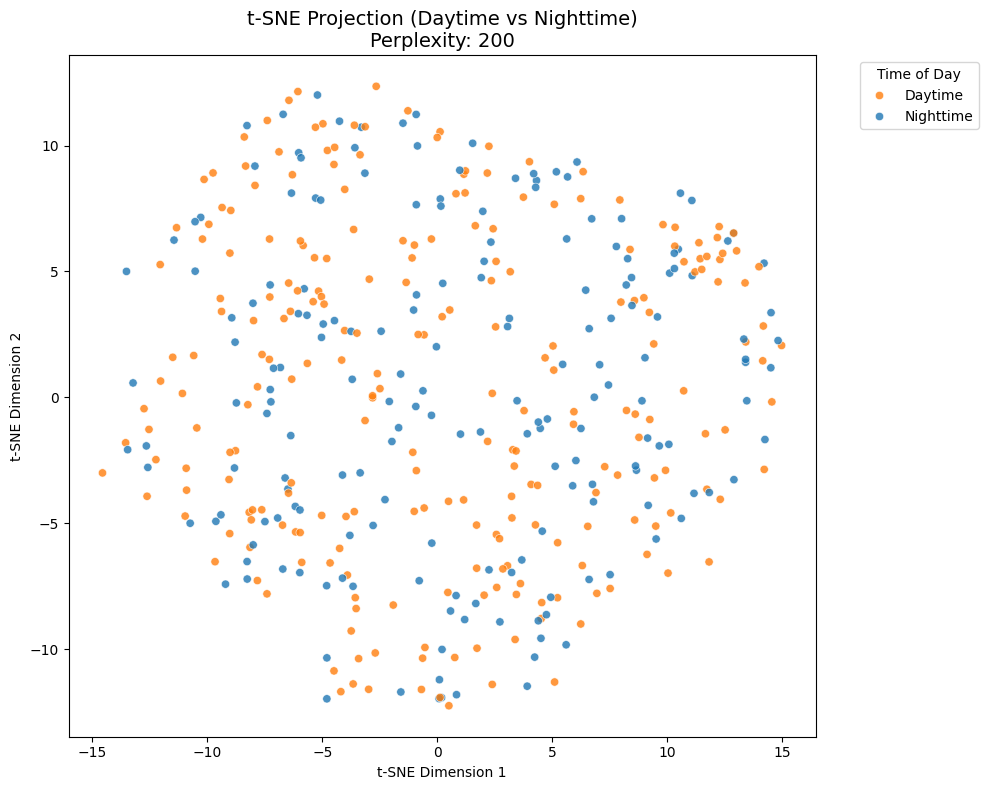

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

# ==========================================
# 🎯 调参中心 (Configuration)
# 每次调参只需要修改这里的值，不要动下面的主体代码
# ==========================================
CONFIG = {
    # 1. 数据参数
    'file_path': r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv",
    'n_samples': 2000,               # 采样数。如果想看全貌可以调到 4000，但计算会变慢
    
    # 2. 特征工程参数
    # 在这里填入你想踢出降维计算的连续特征。
    # 强烈建议踢出 'NMHC(GT)'，因为它的原始数据缺失率高达 90%
    'exclude_features': ['NMHC(GT)'], 
    
    # 3. t-SNE 核心超参数 (针对“点太散”的问题进行调整)
    'tsne_perplexity': 200,           # 【关键】困惑度。默认 30-40。点太散时，增加到 80-100，让算法关注更大的簇
    'tsne_learning_rate': 200,       # 学习率。设为具体数值(如 200)通常比 'auto' 效果更稳定
    'tsne_n_iter': 3000,             # 迭代次数。默认 1000。点未收敛时增加到 2000-3000
    'tsne_init': 'pca',              # 初始化方式，保持 pca 即可
    'random_state': 42               # 随机种子，保证每次跑出来的图一样
}

# ==========================================
# 1. 数据加载与基础准备
# ==========================================
df = pd.read_csv(CONFIG['file_path'])

# 随机抽样
df_sampled = df.sample(n=CONFIG['n_samples'], random_state=CONFIG['random_state']).copy()

# ==========================================
# 2. 特征提取 (X)
# ==========================================
# 原始所有的物理化学连续变量
all_physical_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 
    'T', 'RH', 'AH'
]

# 根据 CONFIG 自动剔除不需要的特征
final_cols = [col for col in all_physical_cols if col not in CONFIG['exclude_features']]
print(f"参与降维的特征共 {len(final_cols)} 个: {final_cols}")

X = df_sampled[final_cols]

# ==========================================
# 3. 运行强化版 t-SNE
# ==========================================
print(f"正在计算 t-SNE (Perplexity={CONFIG['tsne_perplexity']}, Iterations={CONFIG['tsne_n_iter']})...")
tsne = TSNE(
    n_components=2, 
    perplexity=CONFIG['tsne_perplexity'], 
    learning_rate=CONFIG['tsne_learning_rate'],
    n_iter=CONFIG['tsne_n_iter'],
    init=CONFIG['tsne_init'],
    random_state=CONFIG['random_state']
)
tsne_results = tsne.fit_transform(X)

df_tsne = pd.DataFrame({
    't-SNE Dimension 1': tsne_results[:, 0],
    't-SNE Dimension 2': tsne_results[:, 1]
})

# ==========================================
# 4. 图表 1：按照 NO2 传感器读数着色
# ==========================================
y_no2 = df_sampled['PT08.S4(NO2)']
df_tsne['NO2_Level'] = y_no2

plt.figure(figsize=(10, 8))
scatter_no2 = sns.scatterplot(
    x="t-SNE Dimension 1", y="t-SNE Dimension 2",
    hue="NO2_Level", palette="coolwarm", data=df_tsne, alpha=0.8
)

plt.title(f"t-SNE Projection (Colored by NO2)\nPerplexity: {CONFIG['tsne_perplexity']}", fontsize=14)
norm = plt.Normalize(y_no2.min(), y_no2.max())
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
sm.set_array([])
scatter_no2.get_legend().remove()
plt.colorbar(sm, label='Normalized PT08.S4(NO2) Reading')
plt.tight_layout()
plt.show()

# ==========================================
# 5. 图表 2：按照 白天 VS 黑夜 着色
# ==========================================
hour_series = df_sampled.filter(like='H_').idxmax(axis=1).str.replace('H_', '').astype(int)

def get_day_period(hour):
    return 'Daytime' if 7 <= hour <= 19 else 'Nighttime'

df_tsne['TimeOfDay'] = hour_series.apply(get_day_period)

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="t-SNE Dimension 1", y="t-SNE Dimension 2",
    hue="TimeOfDay", palette={"Daytime": "#ff7f0e", "Nighttime": "#1f77b4"}, 
    data=df_tsne, alpha=0.8
)

plt.title(f"t-SNE Projection (Daytime vs Nighttime)\nPerplexity: {CONFIG['tsne_perplexity']}", fontsize=14)
plt.legend(title='Time of Day', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NO2
进行颜色映射时，可以观察到明显的长尾分布现象。图中绝大部分区域属于正常基线水平（浅色），而极少数的高污染“爆表”事件（深色）集中在流形的特定边缘地带，这与交通拥堵或极端天气的偶发性相吻合。

正在计算 3D t-SNE (这会比 2D 稍微慢一点)...


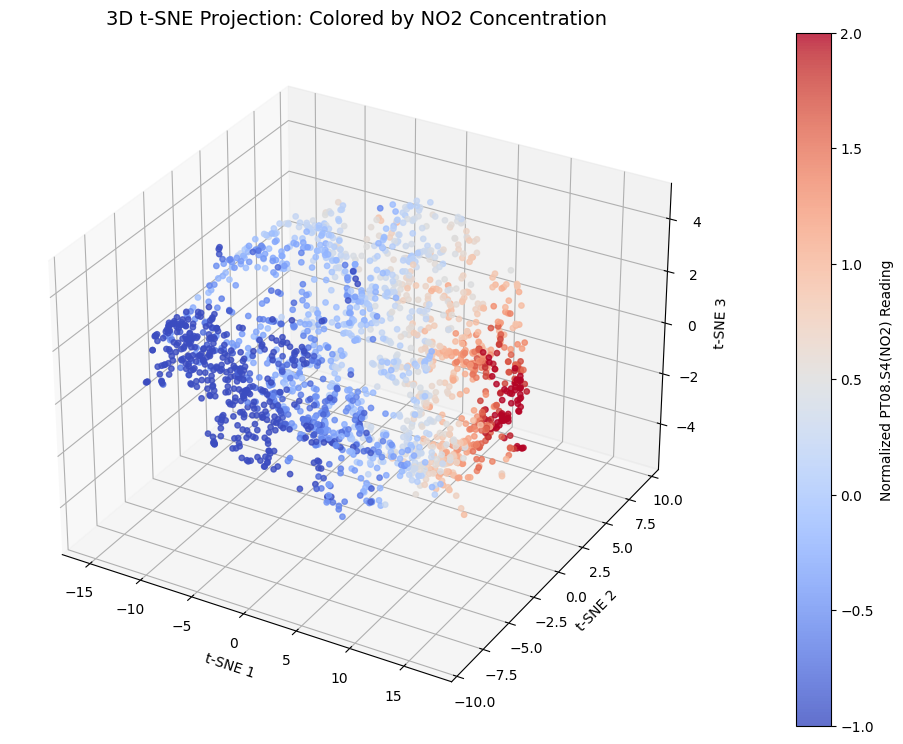

In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)
df_sampled = df.sample(n=2000, random_state=42).copy()

# 提取物理特征 (继续踢出缺失严重的 NMHC)
physical_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]
X = df_sampled[physical_cols]


print("正在计算 3D t-SNE (这会比 2D 稍微慢一点)...")
tsne_3d = TSNE(
    n_components=3,      # 【关键改变】目标维度设为 3
    perplexity=50,       # 降回合理的困惑度
    learning_rate=200,
    n_iter=2000,
    init='pca',
    random_state=42
)
tsne_results_3d = tsne_3d.fit_transform(X)

# 将 3D 坐标存入 DataFrame
df_tsne_3d = pd.DataFrame({
    'TSNE_1': tsne_results_3d[:, 0],
    'TSNE_2': tsne_results_3d[:, 1],
    'TSNE_3': tsne_results_3d[:, 2],
    'NO2_Level': df_sampled['PT08.S4(NO2)'], # 用于渐变着色
})

# ==========================================
# 3. 使用 Plotly 绘制可旋转的 3D 散点图
# ==========================================

# --- 视角 1：按 NO2 浓度着色 (连续渐变) ---
fig1 = plt.figure(figsize=(12, 9))
# projection='3d' 告诉 matplotlib 这是一个三维图
ax1 = fig1.add_subplot(111, projection='3d')

# 绘制 3D 散点
scatter1 = ax1.scatter(
    df_tsne_3d['TSNE_1'], 
    df_tsne_3d['TSNE_2'], 
    df_tsne_3d['TSNE_3'],
    c=df_tsne_3d['NO2_Level'], # 颜色映射值
    cmap='coolwarm', 
    s=15, 
    alpha=0.8,
    vmin=-1.0,     # 设定蓝色的底线
    vmax=2.0                # 透明度
)

# 添加颜色条和标签
fig1.colorbar(scatter1, ax=ax1, label='Normalized PT08.S4(NO2) Reading', pad=0.1)
ax1.set_title('3D t-SNE Projection: Colored by NO2 Concentration', fontsize=14)
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.set_zlabel('t-SNE 3')
plt.show()

T，Traffic Period
流形连续性 (Manifold Continuity): 从 t-SNE 的三维/二维投影中观察到，数据并没有聚集成几个完全孤立的岛屿，而是呈现出连续的流形结构（如心形或带状）。这反映了空气质量数据作为时间序列的本质——物理环境的演变是平滑过渡的。

正在运行 3D t-SNE，请稍候...


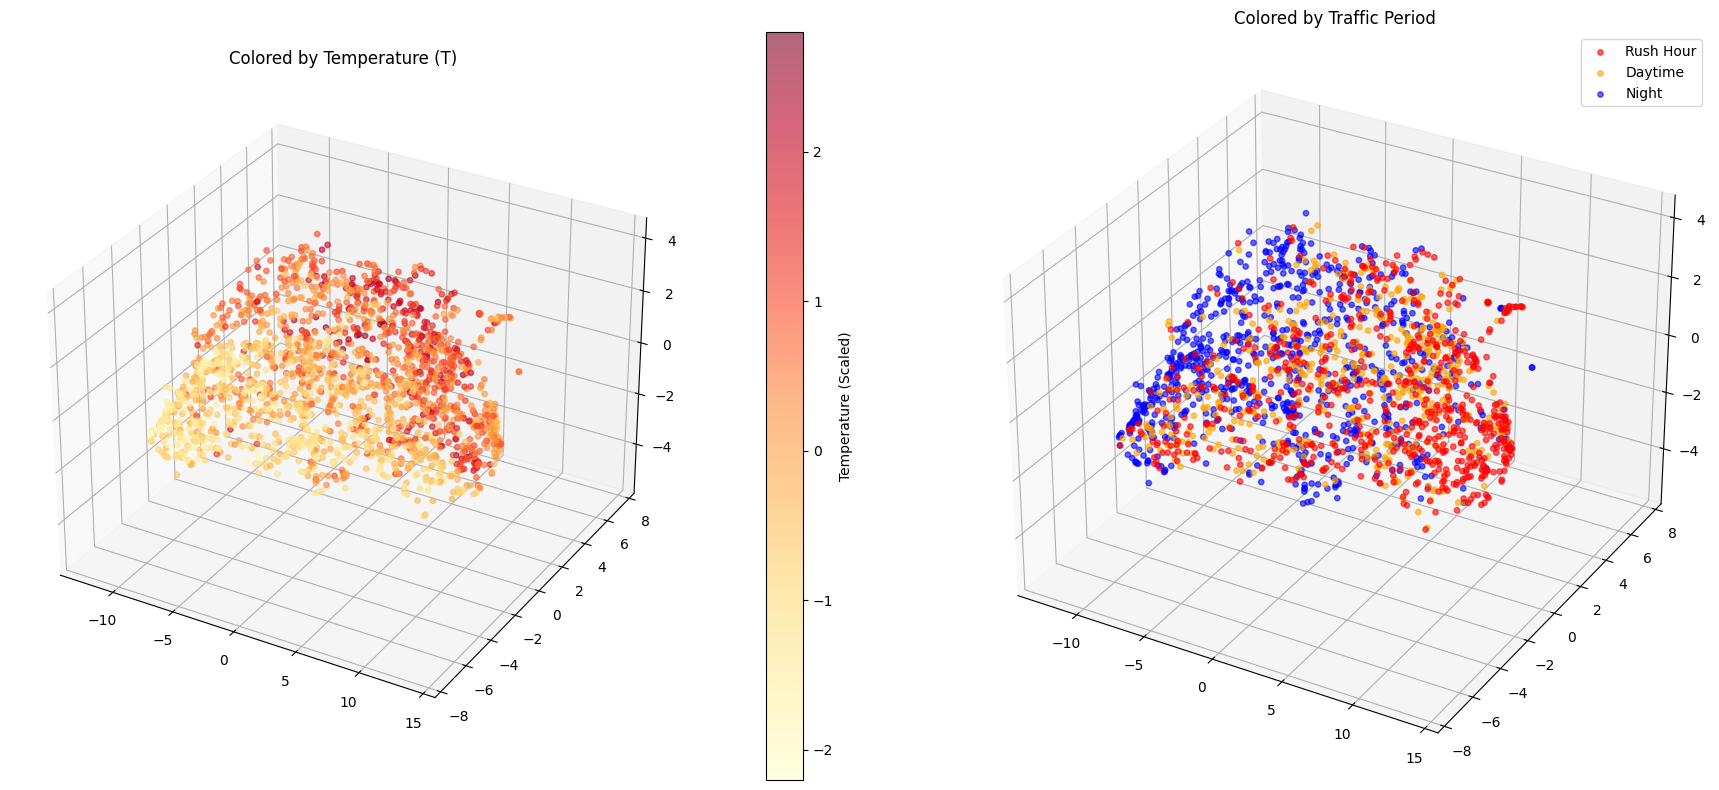

In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. 配置与数据加载
# ==========================================
# 请确保使用你之前生成的那个“包含原始数据和标准化数据”的 CSV
file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)

# 采样，防止计算过慢
n_samples = 2000
df_sampled = df.sample(n=n_samples, random_state=42).copy()

# 【关键点】定义两组特征集进行对比
# 核心污染特征（剔除了 T, RH, AH 干扰）
pollution_only_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]
# 全特征（包含气象干扰）
all_features_cols = pollution_only_cols + ['T', 'RH', 'AH']

# --- 你可以在这里切换 X 的选择 ---
X = df_sampled[pollution_only_cols] # 建议先试这个，看看去掉了温度后颜色是否聚拢

# ==========================================
# 2. 运行 3D t-SNE
# ==========================================
print("正在运行 3D t-SNE, 请稍候...")
tsne = TSNE(
    n_components=3,
    perplexity=75,       # 回到中等水平
    learning_rate=100,
    n_iter=3000,         # 增加迭代次数让它跑得更开
    init='pca',
    random_state=42
)
tsne_results = tsne.fit_transform(X)

# 还原小时并分类（用于视角2对比）
hour_series = df_sampled.filter(like='H_').idxmax(axis=1).str.replace('H_', '').astype(int)
def categorize_time(hour):
    if 7 <= hour <= 10 or 17 <= hour <= 20: return 'Rush Hour'
    elif 11 <= hour <= 16: return 'Daytime'
    else: return 'Night'

# 构建绘图数据框
df_plot = pd.DataFrame({
    'X': tsne_results[:, 0],
    'Y': tsne_results[:, 1],
    'Z': tsne_results[:, 2],
    'Temp': df_sampled['T'],          # 用于温度映射
    'Humidity': df_sampled['RH'],    # 用于湿度映射
    'Traffic': hour_series.apply(categorize_time)
})

# ==========================================
# 3. 绘图对比：验证“天气主导”假说
# ==========================================

# --- 视角 1：按温度着色 (验证是否有天气聚类) ---
fig = plt.figure(figsize=(18, 8))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(df_plot['X'], df_plot['Y'], df_plot['Z'], 
                  c=df_plot['Temp'], cmap='YlOrRd', s=15, alpha=0.6)
fig.colorbar(sc1, ax=ax1, label='Temperature (Scaled)', pad=0.1)
ax1.set_title('Colored by Temperature (T)')

# --- 视角 2：按交通时段着色 (观察是否有逻辑改进) ---
ax2 = fig.add_subplot(122, projection='3d')
colors = {'Rush Hour': 'red', 'Daytime': 'orange', 'Night': 'blue'}
for status, color in colors.items():
    subset = df_plot[df_plot['Traffic'] == status]
    ax2.scatter(subset['X'], subset['Y'], subset['Z'], 
                c=color, label=status, s=15, alpha=0.6)

ax2.legend()
ax2.set_title('Colored by Traffic Period')

plt.tight_layout()
plt.show()

NOx
当使用特定的污染指标进行颜色映射时，可以观察到明显的长尾分布现象。图中绝大部分区域属于正常基线水平（浅色），而极少数的高污染“爆表”事件（深色）集中在流形的特定边缘地带，这与交通拥堵或极端天气的偶发性相吻合。

正在计算 3D t-SNE (这会比 2D 稍微慢一点)...


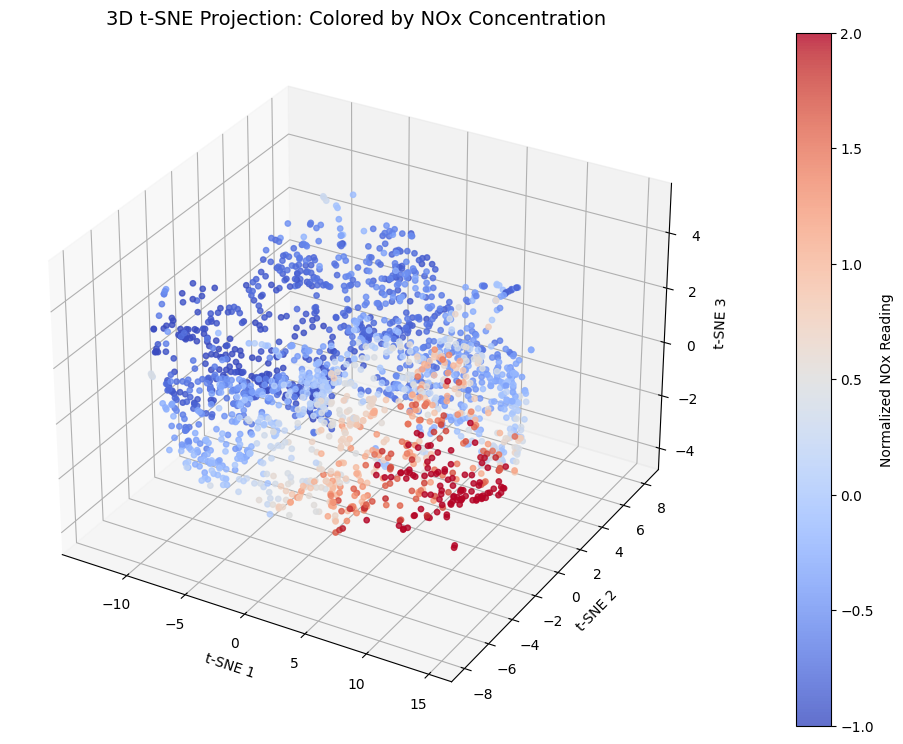

In [39]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


file_path = r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv"
df = pd.read_csv(file_path)
df_sampled = df.sample(n=2000, random_state=42).copy()

physical_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 
    'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)'
]
X = df_sampled[physical_cols]


# 运行 3D t-SNE
print("正在计算 3D t-SNE (这会比 2D 稍微慢一点)...")
tsne_3d = TSNE(
    n_components=3,      
    perplexity=70,       
    learning_rate=200,
    n_iter=3000,
    init='pca',
    random_state=42
)
tsne_results_3d = tsne_3d.fit_transform(X)

# 将 3D 坐标存入 DataFrame
df_tsne_3d = pd.DataFrame({
    'TSNE_1': tsne_results_3d[:, 0],
    'TSNE_2': tsne_results_3d[:, 1],
    'TSNE_3': tsne_results_3d[:, 2],
    'NOx_Level': df_sampled['NOx(GT)'], 
})


fig1 = plt.figure(figsize=(12, 9))
ax1 = fig1.add_subplot(111, projection='3d')

scatter1 = ax1.scatter(
    df_tsne_3d['TSNE_1'], 
    df_tsne_3d['TSNE_2'], 
    df_tsne_3d['TSNE_3'],
    c=df_tsne_3d['NOx_Level'], 
    cmap='coolwarm', 
    s=15, 
    alpha=0.8,
    vmin=-1.0,    
    vmax=2.0              
)

fig1.colorbar(scatter1, ax=ax1, label='Normalized NOx Reading', pad=0.1)
ax1.set_title('3D t-SNE Projection: Colored by NOx Concentration', fontsize=14)
ax1.set_xlabel('t-SNE 1')
ax1.set_ylabel('t-SNE 2')
ax1.set_zlabel('t-SNE 3')
plt.show()

🚀 启动 t-SNE 网格搜索: 4 特征集 x 3 困惑度...
正在跑: 1. Pure Physical | Perplexity: 5 ...
正在跑: 1. Pure Physical | Perplexity: 30 ...
正在跑: 1. Pure Physical | Perplexity: 50 ...
正在跑: 2. Physical + Meteo | Perplexity: 5 ...
正在跑: 2. Physical + Meteo | Perplexity: 30 ...
正在跑: 2. Physical + Meteo | Perplexity: 50 ...
正在跑: 3. CO Related (Temp) | Perplexity: 5 ...
正在跑: 3. CO Related (Temp) | Perplexity: 30 ...
正在跑: 3. CO Related (Temp) | Perplexity: 50 ...
正在跑: 4. Full Features | Perplexity: 5 ...
正在跑: 4. Full Features | Perplexity: 30 ...
正在跑: 4. Full Features | Perplexity: 50 ...


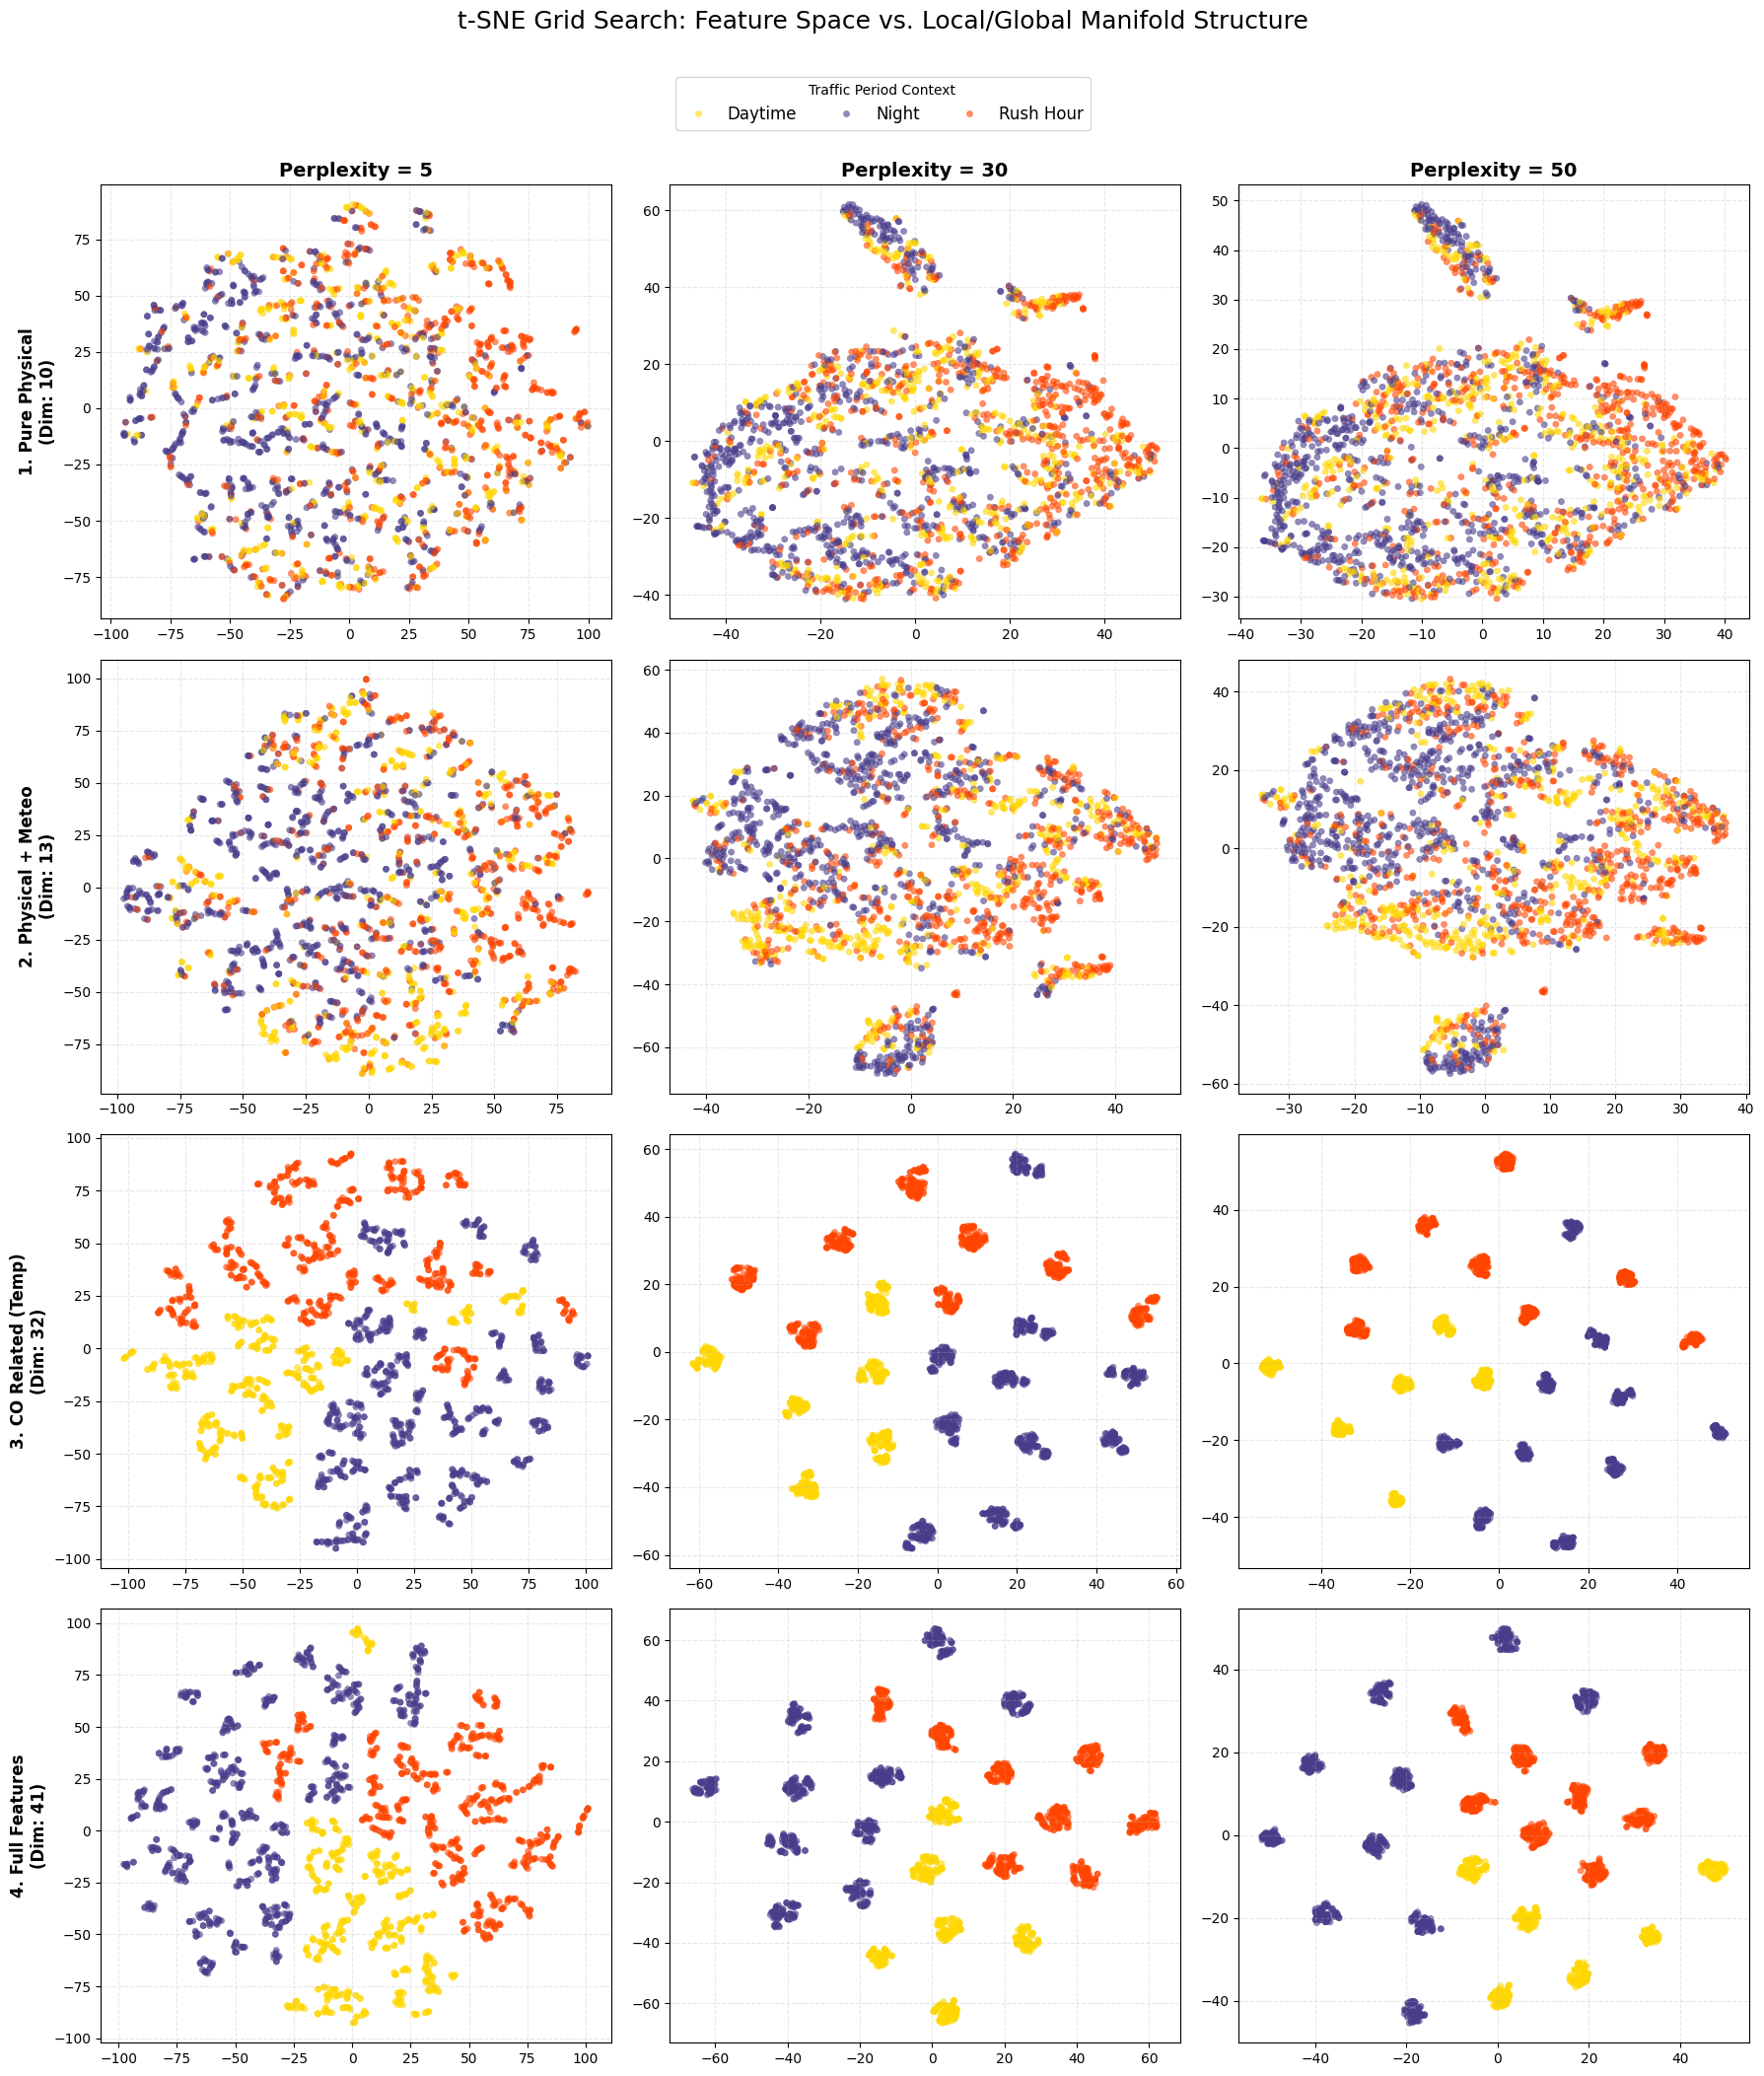

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. 准备数据与特征组
# ==========================================
df = pd.read_csv(r"D:\code\python\ML\Project\air+quality\AirQuality_Fully_Preprocessed.csv")

# 提取用于着色的 Ground Truth (交通时段)
hour_series = df.filter(like='H_').idxmax(axis=1).str.replace('H_', '').astype(int)
def categorize_time(hour):
    if 7 <= hour <= 10 or 17 <= hour <= 20: return "Rush Hour"
    elif 11 <= hour <= 16: return "Daytime"
    else: return "Night"
df['Traffic_Period'] = hour_series.apply(categorize_time)

# 定义要测试的特征集网格
pollutant_cols = ["CO(GT)", "NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
sensor_cols = ["PT08.S1(CO)", "PT08.S2(NMHC)", "PT08.S3(NOx)", "PT08.S4(NO2)", "PT08.S5(O3)"]
meteo_cols = ["T", "RH", "AH"]
temporal_cols = ["Year", "Month", "DayOfWeek"] + [f"H_{i}" for i in range(24)]

# 选取 4 个代表性特征组
feature_grid = {
    "1. Pure Physical": pollutant_cols + sensor_cols,
    "2. Physical + Meteo": pollutant_cols + sensor_cols + meteo_cols,
    "3. CO Related (Temp)": ["CO(GT)", "PT08.S1(CO)"] + meteo_cols + temporal_cols,
    "4. Full Features": list(df.drop(['Traffic_Period'], axis=1).columns)
}

# ==========================================
# 2. t-SNE 网格搜索参数设置
# ==========================================
perplexities = [5, 30, 50]  # 困惑度网格：从局部到全局
sample_size = 2000          # 采样量 (保证搜索效率)
df_sample = df.sample(n=sample_size, random_state=42)

n_rows = len(feature_grid)
n_cols = len(perplexities)

print(f"🚀 启动 t-SNE 网格搜索: {n_rows} 特征集 x {n_cols} 困惑度...")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))

# ==========================================
# 3. 核心搜索循环
# ==========================================
for i, (fs_name, cols) in enumerate(feature_grid.items()):
    # 提取特征并标准化
    valid_cols = [c for c in cols if c in df.columns]
    X = df_sample[valid_cols]
    X_scaled = StandardScaler().fit_transform(X)
    
    for j, px in enumerate(perplexities):
        print(f"正在跑: {fs_name} | Perplexity: {px} ...")
        
        # 运行 t-SNE
        tsne = TSNE(n_components=2, perplexity=px, random_state=42, init='pca', learning_rate='auto')
        X_tsne = tsne.fit_transform(X_scaled)
        
        # 绘图
        ax = axes[i, j]
        sns.scatterplot(
            x=X_tsne[:, 0], y=X_tsne[:, 1], 
            hue=df_sample['Traffic_Period'], 
            palette={'Rush Hour': '#FF4500', 'Daytime': '#FFD700', 'Night': '#483D8B'},
            alpha=0.6, ax=ax, s=20, edgecolor=None
        )
        
        # 标注信息
        if i == 0: ax.set_title(f"Perplexity = {px}", fontsize=14, fontweight='bold')
        if j == 0: ax.set_ylabel(f"{fs_name}\n(Dim: {len(valid_cols)})", fontsize=12, fontweight='bold')
        else: ax.set_ylabel("")
        
        ax.set_xlabel("")
        ax.legend().remove()
        ax.grid(True, linestyle='--', alpha=0.3)

# 统一图例
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.02), ncol=3, title="Traffic Period Context", fontsize=12)

plt.suptitle("t-SNE Grid Search: Feature Space vs. Local/Global Manifold Structure", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()